In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



In [2]:
df = pd.read_csv('2 loan_approval_data.csv')
print(df.head())


   Applicant_ID  Applicant_Income  Coapplicant_Income Employment_Status   Age  \
0           1.0           17795.0              1387.0          Salaried  51.0   
1           2.0            2860.0              2679.0          Salaried  46.0   
2           3.0            7390.0              2106.0          Salaried  25.0   
3           4.0           13964.0              8173.0          Salaried  40.0   
4           5.0           13284.0              4223.0     Self-employed  31.0   

  Marital_Status  Dependents  Credit_Score  Existing_Loans  DTI_Ratio  \
0        Married         0.0         637.0             4.0       0.53   
1        Married         3.0         621.0             2.0       0.30   
2         Single         2.0         674.0             4.0       0.20   
3        Married         2.0         579.0             3.0       0.31   
4         Single         2.0         721.0             1.0       0.29   

   Savings  Collateral_Value  Loan_Amount  Loan_Term Loan_Purpose  \
0  19

In [3]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [4]:
print(df.describe())


       Applicant_ID  Applicant_Income  Coapplicant_Income         Age  \
count    950.000000        950.000000          950.000000  950.000000   
mean     501.220000      10852.571579         5082.455789   39.971579   
std      289.608451       5061.632859         2943.161570   11.139797   
min        1.000000       2009.000000            1.000000   21.000000   
25%      250.250000       6730.750000         2472.750000   30.250000   
50%      499.500000      10548.000000         5205.500000   40.000000   
75%      752.750000      15190.000000         7620.750000   49.000000   
max     1000.000000      19988.000000         9996.000000   59.000000   

       Dependents  Credit_Score  Existing_Loans   DTI_Ratio       Savings  \
count  950.000000    950.000000      950.000000  950.000000    950.000000   
mean     1.474737    676.033684        1.950526    0.347263   9940.452632   
std      1.105067     71.346015        1.406246    0.144341   5860.736885   
min      0.000000    550.000000   

In [5]:
print(df.isnull().sum())

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64


### Handling Missing Values

In [6]:
categorical_cols = df.select_dtypes(include= ['object']).columns
numerical_cols = df.select_dtypes(include= ['number']).columns

In [7]:
categorical_cols.size + numerical_cols.size

20

In [8]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [9]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = 'mean')
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [10]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [11]:
cat_imp = SimpleImputer(strategy = 'most_frequent')
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

### EDA - exploratory data analysis

Text(0.5, 1.0, 'Is Loan Approved or Not?')

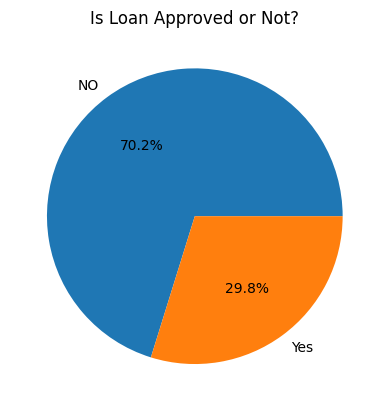

In [12]:
#   How balanced our classes are in the target variable?
classes_count = df['Loan_Approved'].value_counts()

plt.pie(classes_count ,labels = ["NO","Yes"],autopct = "%1.1f%%")
plt.title("Is Loan Approved or Not?")

[Text(0, 0, '621'), Text(0, 0, '379')]

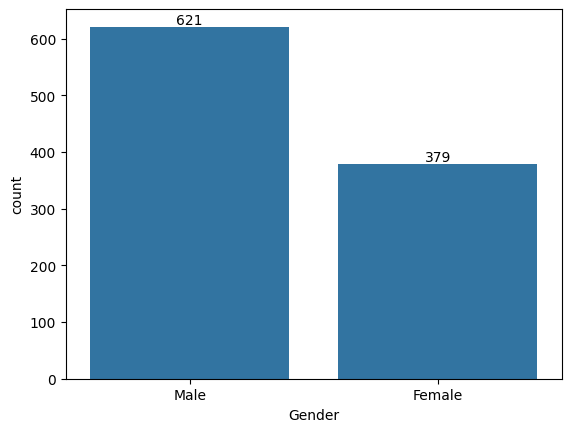

In [13]:
# Analyze categories
gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])



[Text(0, 0, '722'), Text(0, 0, '278')]

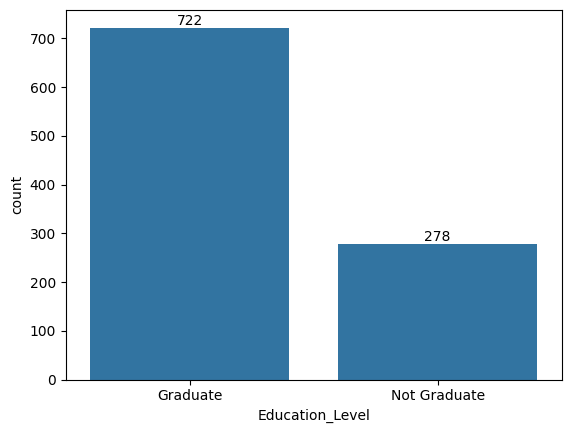

In [14]:
edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

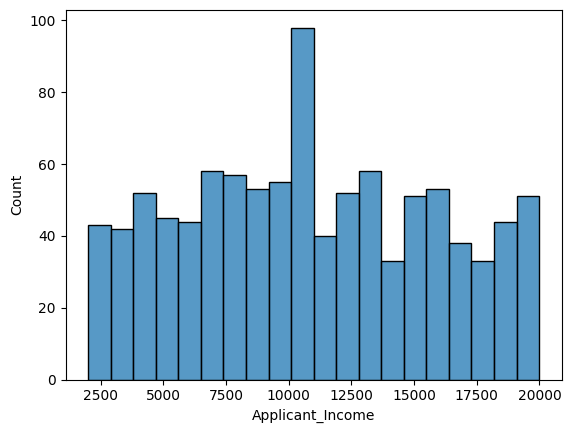

In [15]:
# income analysis
sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20
)

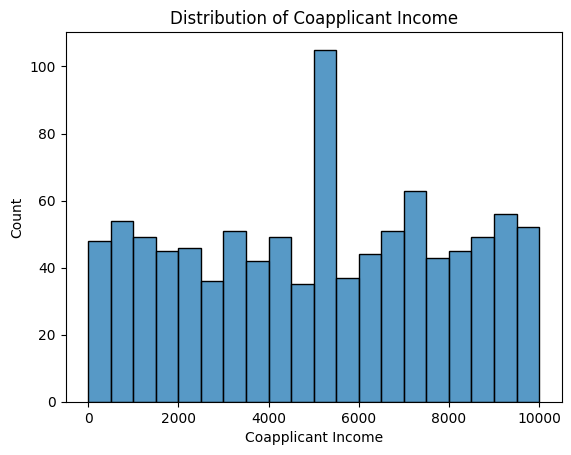

In [16]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    bins=20
)
plt.title("Distribution of Coapplicant Income")
plt.xlabel("Coapplicant Income")
plt.show()

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

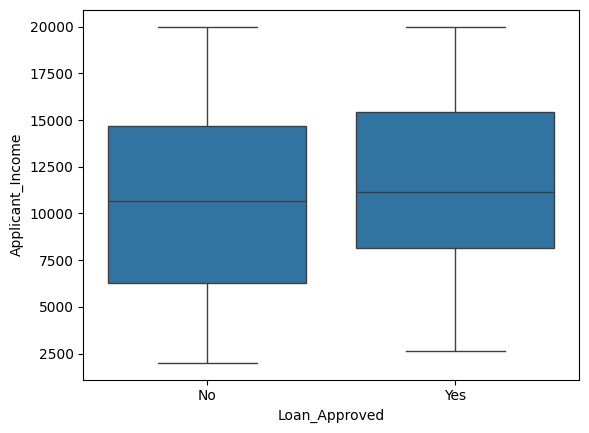

In [17]:
# outlier detection - boxplot
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

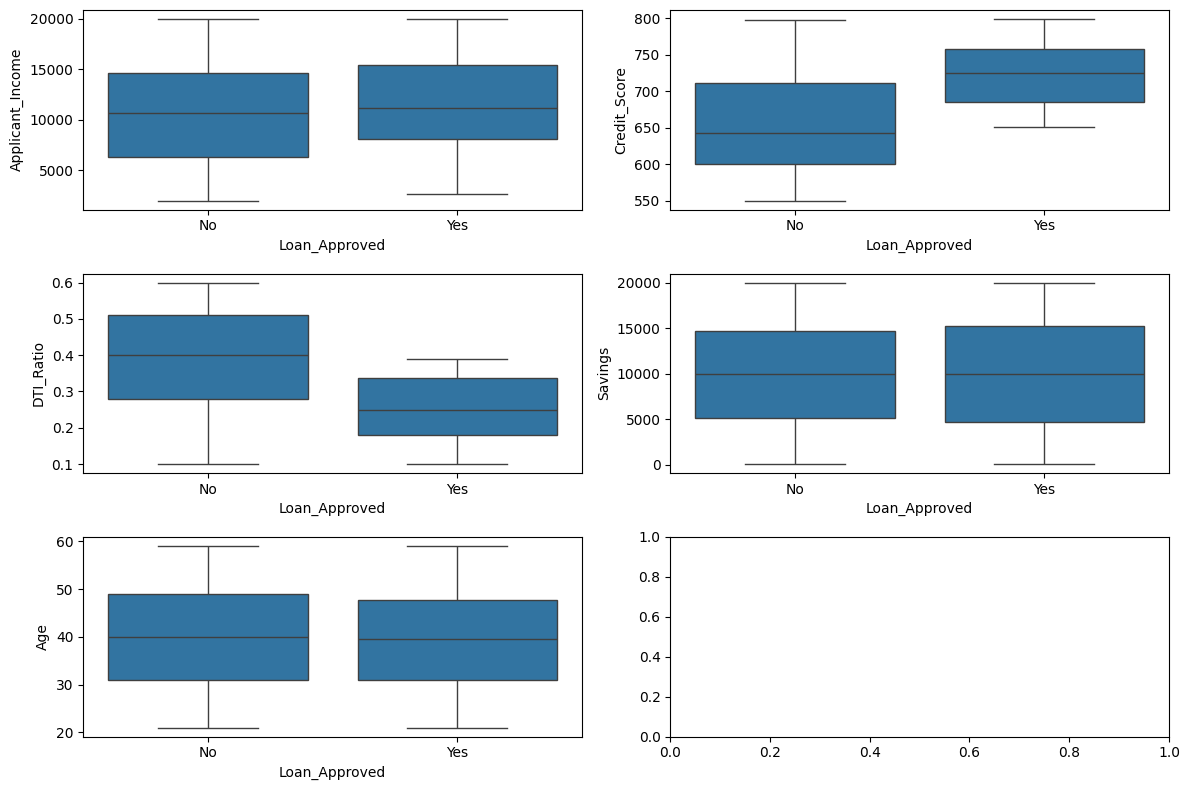

In [18]:
fig , axes = plt.subplots(3,2, figsize = (12,8))

sns.boxplot(ax = axes[0,0],data = df , x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[0,1],data = df , x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[1,0],data = df , x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = axes[1,1],data = df , x = "Loan_Approved",y = "Savings")
sns.boxplot(ax = axes[2,0],data = df , x = "Loan_Approved",y = "Age")
plt.tight_layout()

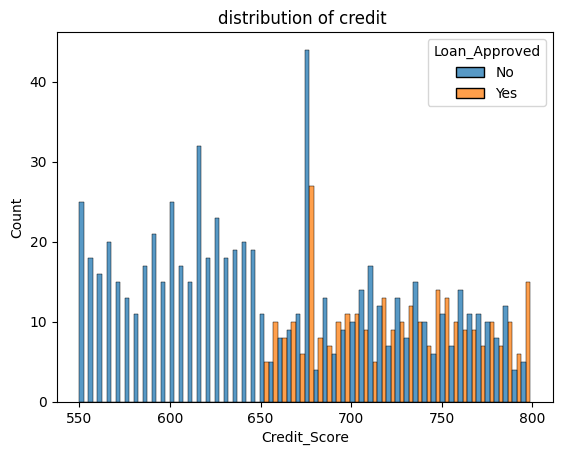

In [19]:
# histogram for numerical features
sns.histplot(x='Credit_Score',data= df,bins = 50 , multiple='dodge', hue = 'Loan_Approved')
plt.title("distribution of credit ")
plt.show()

In [20]:
# Remove Applicant Id
df = df.drop("Applicant_ID",axis = 1)


In [21]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


### Encoding

In [22]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

le = LabelEncoder()
df['Education_Level'] = le.fit_transform(df['Education_Level'])
df['Loan_Approved'] = le.fit_transform(df['Loan_Approved'])

In [23]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [31]:

# Categorical columns
cols = [
    'Employment_Status',
    'Marital_Status',
    'Loan_Purpose',
    'Property_Area',
    'Gender',
    'Employer_Category'
]

# Check which columns are available in the dataframe
available_cols = [col for col in cols if col in df.columns]

if available_cols:

    # Create OneHotEncoder
    ohe = OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    )

    # Apply One-Hot Encoding
    encoded = ohe.fit_transform(df[available_cols])

    # Convert encoded array into DataFrame
    encoded_df = pd.DataFrame(
        encoded,
        columns=ohe.get_feature_names_out(available_cols),
        index=df.index
    )

    # Drop original columns and add encoded columns
    df = pd.concat(
        [
            df.drop(columns=available_cols),
            encoded_df
        ],
        axis=1
    )

    print("One-Hot Encoding completed successfully!")

else:
    print("Categorical columns are already encoded or not found.")

# Check dataframe
print(df.head())
print(df.shape)

Categorical columns are already encoded or not found.
   Applicant_Income  Coapplicant_Income   Age  Dependents  Credit_Score  \
0           17795.0              1387.0  51.0         0.0         637.0   
1            2860.0              2679.0  46.0         3.0         621.0   
2            7390.0              2106.0  25.0         2.0         674.0   
3           13964.0              8173.0  40.0         2.0         579.0   
4           13284.0              4223.0  31.0         2.0         721.0   

   Existing_Loans  DTI_Ratio  Savings  Collateral_Value  Loan_Amount  ...  \
0             4.0       0.53  19403.0           45638.0      16619.0  ...   
1             2.0       0.30   2580.0           49272.0      38687.0  ...   
2             4.0       0.20  13844.0            6908.0      27943.0  ...   
3             3.0       0.31   9553.0           10844.0      27819.0  ...   
4             1.0       0.29   9386.0           37629.0      12741.0  ...   

   Loan_Purpose_Education  Loan_

### Correlation Heatmap

<Axes: >

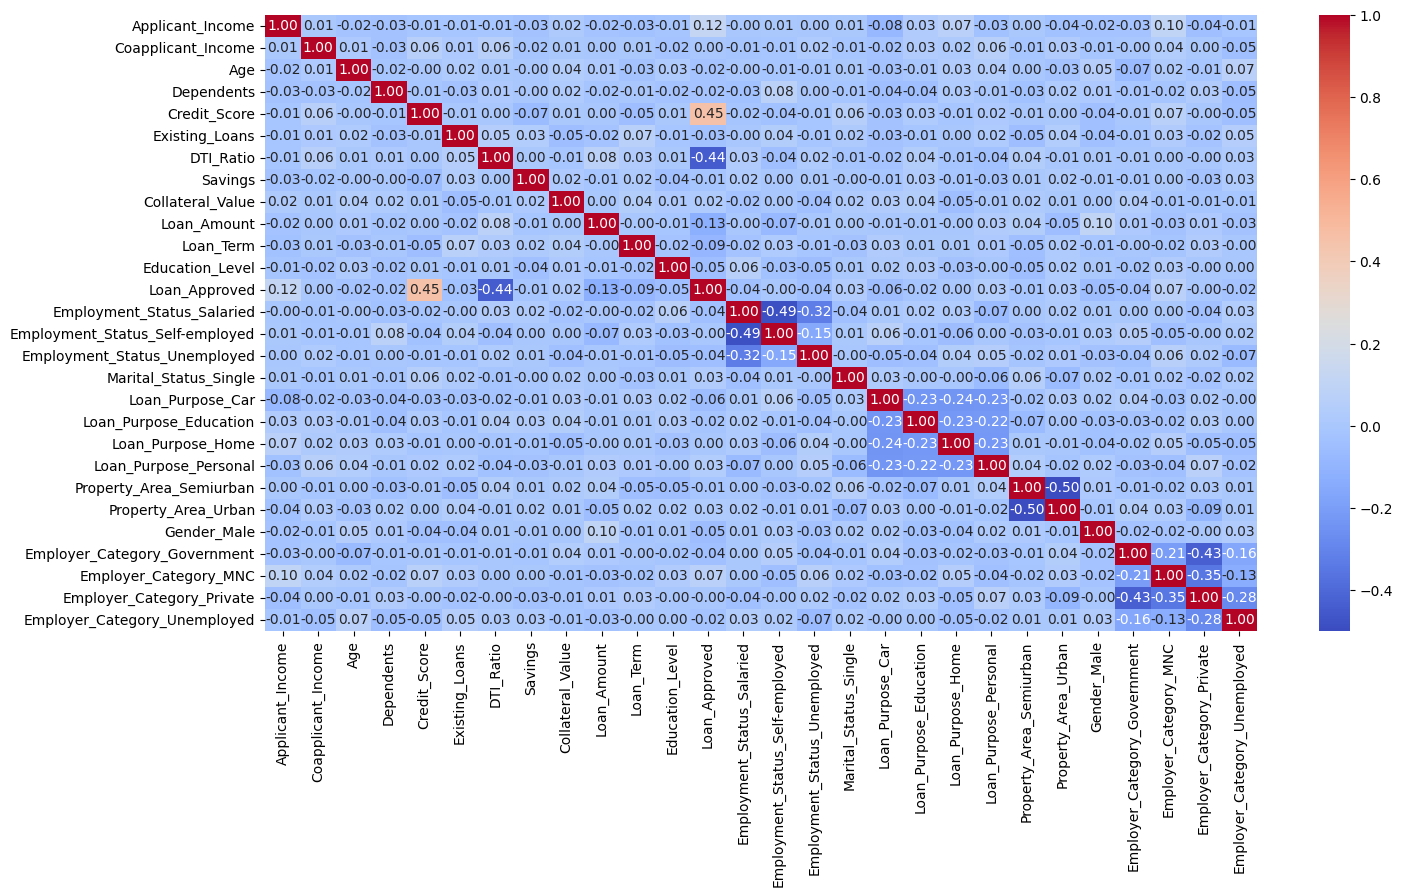

In [32]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize = (16,8))
sns.heatmap(
    corr_matrix,
    annot= True ,
    fmt = ".2f",
    cmap = "coolwarm"
)


In [33]:
corr_matrix["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

### Train-Test-Split + Feature Scaling

In [34]:
X = df.drop("Loan_Approved",axis =1)
y = df["Loan_Approved"]

In [35]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
         2.41611400e+00, -8.59726954e-01, -3.07231582e-01]],
      shape=(800, 27))

### Train & Evaluate Models

In [40]:
# logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score, precision_score,recall_score,f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation metrics
print("Logistic Regression Model :")
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Logistic Regression Model :
Precision : 0.7833333333333333
Recall : 0.7704918032786885
F1 Score : 0.7768595041322314
Accuracy : 0.865
Confusion Matrix :
 [[126  13]
 [ 14  47]]


In [41]:
# knn model
from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train_scaled,y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation metrics
print("K-Nearest Neighbors Model :")
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

K-Nearest Neighbors Model :
Precision : 0.6274509803921569
Recall : 0.5245901639344263
F1 Score : 0.5714285714285714
Accuracy : 0.76
Confusion Matrix :
 [[120  19]
 [ 29  32]]


In [48]:
# Naive Bayes model
from sklearn.naive_bayes import GaussianNB



nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation metrics
print("Naive Bayes Model :")
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Naive Bayes Model :
Precision : 0.8035714285714286
Recall : 0.7377049180327869
F1 Score : 0.7692307692307693
Accuracy : 0.865
Confusion Matrix :
 [[128  11]
 [ 16  45]]


### Best Model on the basis of Prediction => Naive Bayes

### Feature engineering

In [43]:
# Add or Transform features to improve model performance
df["DTI_Ratio_sq"] = df["DTI_Ratio"]**2
df["Credit_Score_sq"] = df["Credit_Score"]**2

df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns = ["Loan_Approved", "DTI_Ratio", "Credit_Score", "Applicant_Income"])
y = df["Loan_Approved"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
X_train.head()

,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Employment_Status_Salaried,...,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq,Applicant_Income_log
29,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0121,363609.000000,8.681181
535,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0441,376996.000000,8.472196
695,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0484,341056.000000,9.292249
557,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.1156,527076.000000,7.776954
836,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0324,457021.542187,8.561975


In [49]:
# logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score, precision_score,recall_score,f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation metrics
print("Logistic Regression Model :")
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Logistic Regression Model :
Precision : 0.7777777777777778
Recall : 0.8032786885245902
F1 Score : 0.7903225806451613
Accuracy : 0.87
Confusion Matrix :
 [[125  14]
 [ 12  49]]


In [50]:
# knn model
from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train_scaled,y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation metrics
print("K-Nearest Neighbors Model :")
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

K-Nearest Neighbors Model :
Precision : 0.6296296296296297
Recall : 0.5573770491803278
F1 Score : 0.591304347826087
Accuracy : 0.765
Confusion Matrix :
 [[119  20]
 [ 27  34]]


In [51]:
# Naive Bayes model
from sklearn.naive_bayes import GaussianNB



nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation metrics
print("Naive Bayes Model :")
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))

Naive Bayes Model :
Precision : 0.8035714285714286
Recall : 0.7377049180327869
F1 Score : 0.7692307692307693
Accuracy : 0.865
Confusion Matrix :
 [[128  11]
 [ 16  45]]
